## The logistic regression is the main algorithm for classification regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score,accuracy_score,f1_score,roc_curve,recall_score,precision_score,confusion_matrix,auc

In [18]:
data=pd.read_csv('Social_Network_Ads.csv')
data.head(20)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [12]:
'''this turns the data into numpy array rather than pandas dataframe
to use it in machine learning model,
cause the numpy array is more faster and lighter 
and the model only deal with number'''
x=data.iloc[:,[2,3]].values
y=data.iloc[:,4].values 
x

array([[    19,  19000],
       [    35,  20000],
       [    26,  43000],
       [    27,  57000],
       [    19,  76000],
       [    27,  58000],
       [    27,  84000],
       [    32, 150000],
       [    25,  33000],
       [    35,  65000],
       [    26,  80000],
       [    26,  52000],
       [    20,  86000],
       [    32,  18000],
       [    18,  82000],
       [    29,  80000],
       [    47,  25000],
       [    45,  26000],
       [    46,  28000],
       [    48,  29000],
       [    45,  22000],
       [    47,  49000],
       [    48,  41000],
       [    45,  22000],
       [    46,  23000],
       [    47,  20000],
       [    49,  28000],
       [    47,  30000],
       [    29,  43000],
       [    31,  18000],
       [    31,  74000],
       [    27, 137000],
       [    21,  16000],
       [    28,  44000],
       [    27,  90000],
       [    35,  27000],
       [    33,  28000],
       [    30,  49000],
       [    26,  72000],
       [    27,  31000],


In [6]:
                                                                              # save the percentage of each type in the train data and test data
                                                                              # like 20% yes and 80% no in all the datasets    
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.3,random_state=42,stratify=y)

## Normalization

In [7]:
# turn the data into standard normal distribution 
scale=StandardScaler()
# fit calculate the statistics for the data set and we need it only
# in the train data not testing data to learn the parameters from the train data and
# apply it to the test data
xtrain=scale.fit_transform(xtrain)
xtest=scale.transform(xtest)

## Model training

In [8]:
model=LogisticRegression()
model.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
# prediction based on the test data
ypred=model.predict(xtest)

## Evaluation

In [10]:
cm=confusion_matrix(ytest,ypred)
# print(f'confusion matrix = \n{cm}')
accs=accuracy_score(ytest,ypred)
print(f'accuracy = {accs}')
rs=recall_score(ytest,ypred)
print(f'recall = {rs}')
ps=precision_score(ytest,ypred)
print(f'precision = {ps}')
f1=f1_score(ytest,ypred)
print(f'f1 score = {f1}')
# its best to use the probabilities of the y prediction to get more accuracy
ras=roc_auc_score(ytest,model.predict_proba(xtest)[:,1])
print(f'AUC score = {ras}')


accuracy = 0.85
recall = 0.6976744186046512
precision = 0.8571428571428571
f1 score = 0.7692307692307693
AUC score = 0.9175475687103594


## The ROC Curve 
The curve tells us about the best fit model.
The curve is the best when he is near to the top left,
random when he is near to the middle,
very bad when he is under the middle.

0.9175475687103594


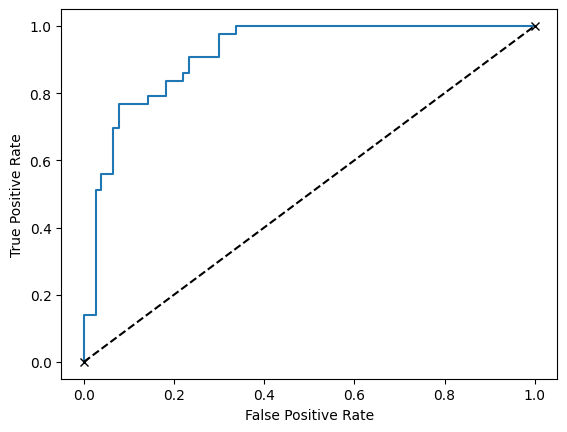

In [11]:
                            #this line gives me the probabilities of each class not the normal prediction
# after the probabilities the code will return a numpy array the contains the probabilities of each class
                                                            #here we choose the probabilities of class 1 (positive) only
fpr,tpr,thresholds=roc_curve(ytest,model.predict_proba(xtest)[:,1])
plt.plot(fpr,tpr,label='Logistic Regression')
                    #this is for the line
plt.plot([0,1],[0,1],'kx--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#! area under curve
roc_auc=auc(fpr,tpr)
print(roc_auc)

## New value prediction

In [29]:
prdiction=[[47,20000]]
prdiction=scale.transform(prdiction)
result=model.predict(prdiction)
print(result)

[0]
